# LeNet-5 Benchmarking: Evaluating Historical CNN Architecture on MNIST and CIFAR-10

## Executive Summary
This notebook explores the performance, adaptability, and historical constraints of **LeNet-5**—one of the foundational Convolutional Neural Network (CNN) architectures introduced by Yann LeCun et al. (1998).

The goal is to evaluate how a early deep learning model designed for monochrome handwritten digits scales to complex, multi-channel natural image classification.

---

## 🔬 Experimental Setup
* **Architecture:** LeNet-5 (Tanh activations, Average Pooling, SGD Optimizer)
* **Datasets:**
  * **MNIST:** $28 \times 28 \times 1$ grayscale images (Handwritten Digits)
  * **CIFAR-10:** $32 \times 32 \times 3$ RGB color images (Real-world Objects)
* **Preprocessing:**
  * Pixel values normalized to $[0, 1]$.
  * MNIST Input spatial dimensions scaled/padded to $32 \times 32$.

---

## 💡 Key Research Questions
1. How efficiently does LeNet-5 generalize from simple structural patterns (MNIST) to complex intra-class color features (CIFAR-10)?
2. What are the representational limits of a lightweight 1990s CNN architecture on modern vision benchmarks?

In [ ]:
import numpy as np
import tensorflow as tf
import tensorflow.keras.layers as tfl
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from datasets import load_dataset

In [2]:
ds_mnist = load_dataset("ylecun/mnist")
ds_cifar10 = load_dataset("uoft-cs/cifar10")

README.md:   0%|          | 0.00/6.97k [00:00<?, ?B/s]

mnist/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 15.6MB            

mnist/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

mnist/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.60MB            

mnist/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.9MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [3]:
print(ds_mnist)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})


In [4]:
print(ds_cifar10)

DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})


In [5]:
def prepare_data(ds):

    # Determine the correct key for images in the dataset
    img_key = 'image' if 'image' in ds['train'].column_names else 'img'

    X_train = np.array([np.array(img) for img in ds['train'][img_key]])
    y_train = np.array(ds['train']['label'])

    X_test = np.array([np.array(img) for img in ds['test'][img_key]])
    y_test = np.array(ds['test']['label'])

    # Normalize image vectors
    X_train = X_train.astype("float32") / 255.0
    X_test = X_test.astype("float32") / 255.0

    # Split the training data into train and validation sets
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

    # Adding a channel dimension to the images if they are from mnist dataset
    if X_train.ndim == 3:
        X_train = np.expand_dims(X_train, axis=-1)
        X_val = np.expand_dims(X_val, axis=-1)
        X_test = np.expand_dims(X_test, axis=-1)
        X_train = np.pad(X_train, ((0,0), (2,2), (2,2), (0,0)), mode='constant')
        X_val = np.pad(X_val, ((0,0), (2,2), (2,2), (0,0)), mode='constant')
        X_test = np.pad(X_test, ((0,0), (2,2), (2,2), (0,0)), mode='constant')

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

In [6]:
(X_train_mnist, y_train_mnist), (X_val_mnist, y_val_mnist), (X_test_mnist, y_test_mnist) = prepare_data(ds_mnist)
(X_train_cifar10, y_train_cifar10), (X_val_cifar10, y_val_cifar10), (X_test_cifar10, y_test_cifar10) = prepare_data(ds_cifar10)

In [7]:
print ("number of training examples = " + str(X_train_mnist.shape[0]))
print ("number of test examples = " + str(X_test_mnist.shape[0]))
print ("X_train shape: " + str(X_train_mnist.shape))
print ("Y_train shape: " + str(y_train_mnist.shape))
print ("X_test shape: " + str(X_test_mnist.shape))
print ("Y_test shape: " + str(y_test_mnist.shape))

number of training examples = 54000
number of test examples = 10000
X_train shape: (54000, 32, 32, 1)
Y_train shape: (54000,)
X_test shape: (10000, 32, 32, 1)
Y_test shape: (10000,)


In [8]:
print ("number of training examples = " + str(X_train_cifar10.shape[0]))
print ("number of test examples = " + str(X_test_cifar10.shape[0]))
print ("X_train shape: " + str(X_train_cifar10.shape))
print ("Y_train shape: " + str(y_train_cifar10.shape))
print ("X_test shape: " + str(X_test_cifar10.shape))
print ("Y_test shape: " + str(y_test_cifar10.shape))

number of training examples = 45000
number of test examples = 10000
X_train shape: (45000, 32, 32, 3)
Y_train shape: (45000,)
X_test shape: (10000, 32, 32, 3)
Y_test shape: (10000,)


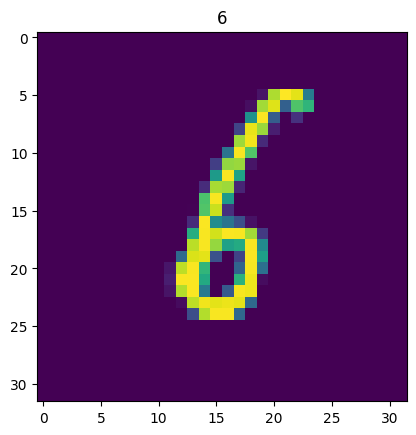

In [9]:
index = np.random.randint(0, X_train_mnist.shape[0]) # generate a random index
plt.imshow(X_train_mnist[index]) # display sample training image
plt.title(y_train_mnist[index])
plt.show()

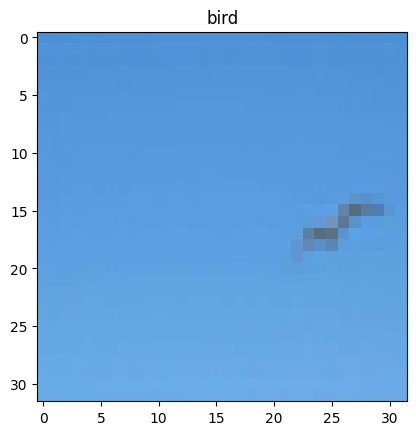

In [10]:
class_names = ds_cifar10['train'].features['label'].names # get class names from the dataset features
index = np.random.randint(0, X_train_cifar10.shape[0]) # generate a random index
plt.imshow(X_train_cifar10[index]) # display sample training image
plt.title(class_names[y_train_cifar10[index]])
plt.show()

In [11]:
# Creating TensorFlow datasets from the numpy arrays
train_mnist_dataset = tf.data.Dataset.from_tensor_slices((X_train_mnist, y_train_mnist))
val_mnist_dataset = tf.data.Dataset.from_tensor_slices((X_val_mnist, y_val_mnist))
test_mnist_dataset = tf.data.Dataset.from_tensor_slices((X_test_mnist, y_test_mnist))

# Shuffling and batching the datasets
BATCH_SIZE = 64
train_mnist_dataset = train_mnist_dataset.shuffle(buffer_size=10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_mnist_dataset = val_mnist_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_mnist_dataset = test_mnist_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [12]:
# Creating TensorFlow datasets from the numpy arrays
train_cifar10_dataset = tf.data.Dataset.from_tensor_slices((X_train_cifar10, y_train_cifar10))
val_cifar10_dataset = tf.data.Dataset.from_tensor_slices((X_val_cifar10, y_val_cifar10))
test_cifar10_dataset = tf.data.Dataset.from_tensor_slices((X_test_cifar10, y_test_cifar10))

# Shuffling and batching the datasets
BATCH_SIZE = 64
train_cifar10_dataset = train_cifar10_dataset.shuffle(buffer_size=10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_cifar10_dataset = val_cifar10_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_cifar10_dataset = test_cifar10_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [13]:
def lenet5(input_shape):
    model = tf.keras.Sequential([
        tfl.Input(shape=input_shape),
        tfl.Conv2D(filters=6, kernel_size=(5, 5), activation='tanh'),
        tfl.AveragePooling2D(pool_size=(2, 2)),
        tfl.Conv2D(filters=16, kernel_size=(5, 5), activation='tanh'),
        tfl.AveragePooling2D(pool_size=(2, 2)),
        tfl.Conv2D(filters=120, kernel_size=(5, 5), activation='tanh'),
        tfl.Flatten(),
        tfl.Dense(units=84, activation='tanh'),
        tfl.Dense(units=10, activation='softmax')
    ])
    return model

In [14]:
lenet5(X_train_mnist.shape[1:]).summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model_mnist = lenet5(X_train_mnist.shape[1:])
model_cifar10 = lenet5(X_train_cifar10.shape[1:])

In [16]:
model_mnist.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy', # ili 'categorical_crossentropy' ako koristiš one-hot
    metrics=['accuracy']
)
model_cifar10.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy', # ili 'categorical_crossentropy' ako koristiš one-hot
    metrics=['accuracy']
)

In [17]:
history_mnist = model_mnist.fit(
    train_mnist_dataset,
    epochs=10,
    validation_data=val_mnist_dataset
    )

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.7571 - loss: 0.9975 - val_accuracy: 0.8887 - val_loss: 0.4329
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 52s 52ms/step - accuracy: 0.8974 - loss: 0.3709 - val_accuracy: 0.9127 - val_loss: 0.3137
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 71s 39ms/step - accuracy: 0.9147 - loss: 0.2988 - val_accuracy: 0.9250 - val_loss: 0.2629
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 36s 43ms/step - accuracy: 0.9256 - loss: 0.2568 - val_accuracy: 0.9327 - val_loss: 0.2283
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 51ms/step - accuracy: 0.9347 - loss: 0.2238 - val_accuracy: 0.9418 - val_loss: 0.1983
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.9429 - loss: 0.1959 - val_accuracy: 0.9485 - val_loss: 0.1745
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 40ms/step - accuracy: 0.9493 - loss: 0.1731 - val_accuracy: 0.9567 - val_loss: 0.1547
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9544 - loss: 0.1539 - 

In [ ]:
history_cifar10 = model_cifar10.fit(
    train_cifar10_dataset,
    epochs=10,
    validation_data=val_cifar10_dataset
    )

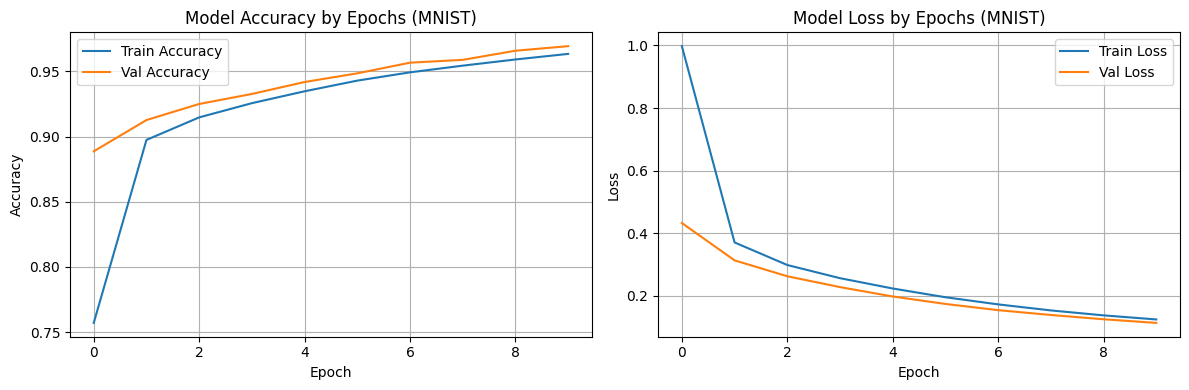

In [18]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_mnist.history['accuracy'], label='Train Accuracy')
plt.plot(history_mnist.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy by Epochs (MNIST)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# 2. Prikaz gubitka (Loss)
plt.subplot(1, 2, 2)
plt.plot(history_mnist.history['loss'], label='Train Loss')
plt.plot(history_mnist.history['val_loss'], label='Val Loss')
plt.title('Model Loss by Epochs (MNIST)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

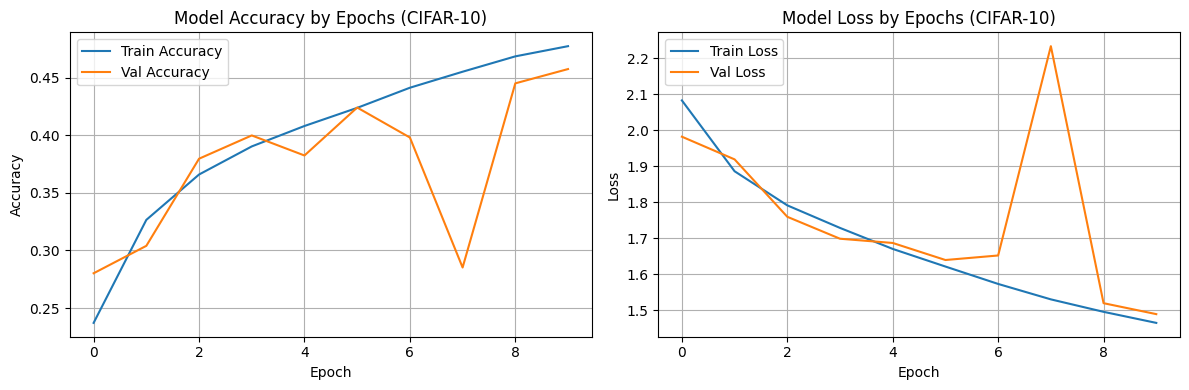

In [19]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_cifar10.history['accuracy'], label='Train Accuracy')
plt.plot(history_cifar10.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy by Epochs (CIFAR-10)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# 2. Prikaz gubitka (Loss)
plt.subplot(1, 2, 2)
plt.plot(history_cifar10.history['loss'], label='Train Loss')
plt.plot(history_cifar10.history['val_loss'], label='Val Loss')
plt.title('Model Loss by Epochs (CIFAR-10)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
test_loss_mnist, test_acc_mnist = model_mnist.evaluate(test_mnist_dataset)
print(f"Final Accuracy on Test Set (MNIST): {test_acc_mnist * 100:.2f}%")

test_loss_cifar10, test_acc_cifar10 = model_cifar10.evaluate(test_cifar10_dataset)
print(f"Final Accuracy on Test Set (CIFAR-10): {test_acc_cifar10 * 100:.2f}%")

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9665 - loss: 0.1141
Final Accuracy on Test Set (MNIST): 96.65%
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4548 - loss: 1.4999
Final Accuracy on Test Set (CIFAR-10): 45.48%


# 📊 6. Experimental Results & Final Conclusion

## Performance Comparison

| Metric | MNIST Dataset | CIFAR-10 Dataset |
| :--- | :---: | :---: |
| **Input Shape** | $(32, 32, 1)$ | $(32, 32, 3)$ |
| **Test Accuracy** | **96.65%** | **45.48%** |
| **Primary Challenge** | Structural digit variance | High intra-class variance & RGB complexity |

---

## Key Takeaways & Analysis

### 1. High Efficiency on Structural Monochromatic Data (MNIST)
LeNet-5 achieves strong classification performance (**96.65%**) on MNIST. Its feature extractor ($6 \to 16$ convolutional channels) is well-suited for isolating edge-based patterns and spatial loops inherent to isolated digits.

### 2. Capacity Constraints on Natural Complex Images (CIFAR-10)
When exposed to CIFAR-10, performance drops significantly to **45.48%**. This performance ceiling is attributed to:
* **Limited Channel Capacity:** 6 and 16 feature maps are insufficient to encapsulate complex RGB textures, backgrounds, and varying perspectives.
* **Intra-class Variance:** Real-world classes (e.g., *cat* vs *dog*) share overlapping backgrounds and features, requiring deeper representation power.
* **Historical Activations:** Standard `tanh` activation functions suffer from gradient decay compared to modern `ReLU` variants on complex loss landscapes.

### 3. Historical Significance
This benchmark visually demonstrates the evolution of Computer Vision: LeNet-5 remains an efficient, lightweight baseline for simple OCR tasks, but highlights the necessity of modern deeper architectures (e.g., ResNet, VGG) for real-world object recognition.